# Perceptron Trick
Here we are performing the perceptron trick on a toy dataset created with `make_classification` from `sklearn.datasets`.

**Steps:** create data → plot it → train the perceptron → draw the learned line → animate the training.

In [3]:
# Step 1: Create a toy dataset
from sklearn.datasets import make_classification
import numpy as np

# 100 points, 2 features (so we can plot them in 2D), 2 classes (0 and 1)
# n_informative=1  -> only one feature actually separates the classes
# class_sep=10     -> classes are far apart, so a straight line can separate them
# random_state=41  -> same data every time the cell is run
x,y = make_classification(n_samples= 100,n_features=2,n_informative=1,n_redundant=0,
n_classes=2,n_clusters_per_class=1,random_state=41,hypercube=False,class_sep=10
)

Matplotlib is building the font cache; this may take a moment.


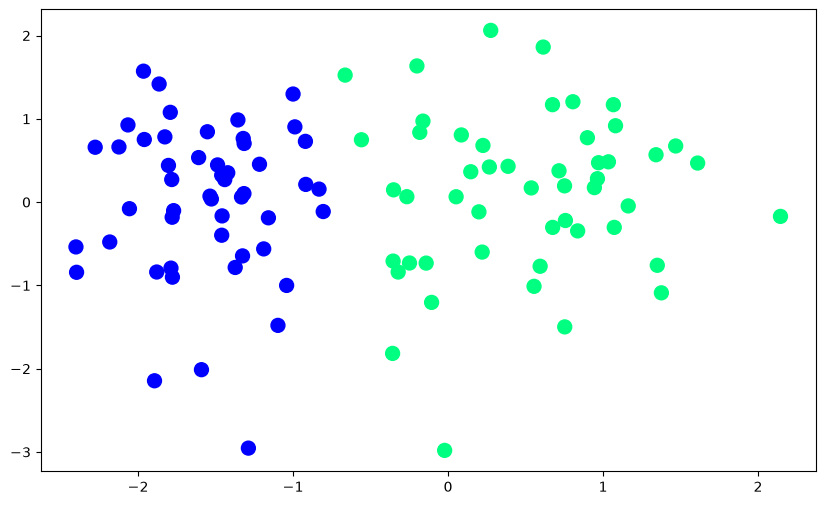

In [6]:
# Step 2: Visualise the data
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
# x[:,0] = feature 1 (horizontal axis), x[:,1] = feature 2 (vertical axis)
# c=y colours each point by its class (blue = 0, green = 1)
plt.scatter(x[:,0],x[:,1],c=y,cmap='winter',s=100)


In [8]:
# Step 3: The perceptron trick (training)
def preceptron(x,y):
    # Add a column of 1s at the front so weights[0] acts as the bias (intercept)
    x = np.insert(x,0,1,axis=1)
    # Start with all weights = 1: [bias, w1, w2]
    weights = np.ones(x.shape[1])
    # Learning rate: how big a step each correction takes
    lr = 0.1
    
    for i in range(1000):
        # Pick one random training point
        j = np.random.randint(0,100)
        # Predict its class with the current line (1 or 0)
        y_hat = step(np.dot(x[j],weights))
        # Perceptron rule: w = w + lr * (actual - predicted) * x
        #   correct prediction   -> (y - y_hat) = 0,  weights unchanged
        #   predicted 0, was 1   -> (y - y_hat) = +1, line moves towards the point
        #   predicted 1, was 0   -> (y - y_hat) = -1, line moves away from the point
        weights = weights + lr*(y[j]-y_hat)*x[j]
    # Return the bias and the feature weights separately
    return weights[0],weights[1:]    

In [9]:
# Step 4: Step (activation) function
# Turns the weighted sum into a class label: positive -> 1, otherwise -> 0
def step(z) :
    return 1 if z > 0 else 0

7.399999999999991
[29.86983883 28.11773182]


(-3.0, 2.0)

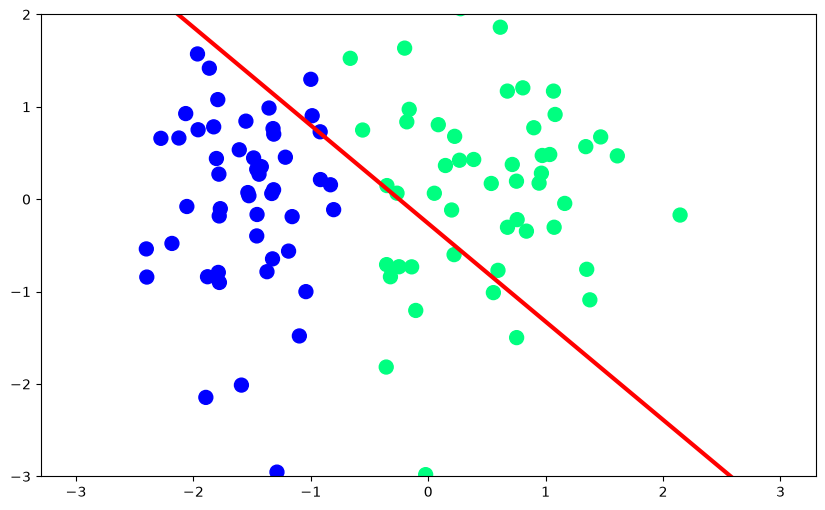

In [52]:
# Step 5: Train the model and draw the learned line
intercept_,coef_ = preceptron(x,y)
print(intercept_)   # bias (w0)
print(coef_)        # feature weights [w1, w2]

# The decision boundary is where w0 + w1*x1 + w2*x2 = 0
# Rearranged into line form x2 = a*x1 + b:
a = -(coef_[0]/coef_[1])      # slope
b = -(intercept_/coef_[1])    # y-intercept

# 100 evenly spaced x values across the plot, and the matching y values on the line
x_input = np.linspace(-3,3,100)
y_input = a*x_input + b

# Plot the line (red) on top of the data points
plt.figure(figsize=(10,6))
plt.plot(x_input,y_input,color='red',linewidth=3)
plt.scatter(x[:,0],x[:,1],c=y,cmap='winter',s=100)
plt.ylim(-3,2)   # keep the view on the data

## Animation: watching the decision boundary learn
Same perceptron trick, but the weights are saved after every step so we can replay how the line moves.

In [53]:
# Step 6: Animate how the line moves during training
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# Same training as preceptron(), but save a copy of the weights after every step
def preceptron_with_history(x,y,epochs=1000,lr=0.1):
    x = np.insert(x,0,1,axis=1)          # add bias column of 1s
    weights = np.ones(x.shape[1])        # start weights = [1, 1, 1]
    history = [weights.copy()]           # remember the starting line
    for i in range(epochs):
        j = np.random.randint(0,x.shape[0])            # pick a random point
        y_hat = step(np.dot(x[j],weights))             # predict its class
        weights = weights + lr*(y[j]-y_hat)*x[j]       # perceptron update
        history.append(weights.copy())                 # save weights after this step
    return history

history = preceptron_with_history(x,y)
frames = history[::10]   # every 10th step keeps the animation short

# Set up the figure once: data points stay fixed, only the line changes
fig, ax = plt.subplots(figsize=(10,6))
ax.scatter(x[:,0],x[:,1],c=y,cmap='winter',s=100)
line, = ax.plot([],[],color='red',linewidth=3)   # empty line, filled in each frame
title = ax.set_title('')
ax.set_xlim(-3,3)
ax.set_ylim(-3,2)
x_input = np.linspace(-3,3,100)

# Called for each frame i: redraw the line using the weights saved at that step
def update(i):
    w = frames[i]                 # w = [bias, w1, w2]
    a = -(w[1]/w[2])              # slope
    b = -(w[0]/w[2])              # y-intercept
    line.set_data(x_input, a*x_input + b)
    title.set_text(f'Step {i*10}   intercept={w[0]:.2f}   coef={w[1]:.2f}, {w[2]:.2f}')
    return line, title

# Build the animation: one frame per saved step, 100 ms between frames
anim = FuncAnimation(fig, update, frames=len(frames), interval=100, blit=True)
plt.close(fig)   # hide the static figure, show only the animation
# Show it in the notebook with play/pause controls
HTML(anim.to_jshtml())